# Приказ Кошијеве расподеле
### Пројекат из вероватноће и статистике — IV разред математичке гимназије

---

> *Постоје расподеле које се понашају тачно онако како очекујемо — а онда постоји Кошијева расподела.*

Овај ноутбук истражује једну од најзанимљивијих и најнеинтуитивнијих расподела у математици — расподелу која **нема очекивање, нема варијансу**, и за коју централна гранична теорема **не важи**.

In [ ]:
# Увоз свих потребних библиотека
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Глобалне поставке за лепши изглед графика
plt.rcParams['figure.facecolor'] = "#E7E7E7"
plt.rcParams['axes.facecolor']   = "#FFFFFF"
plt.rcParams['axes.edgecolor']   = "#a8a8a8"
plt.rcParams['axes.labelcolor']  = "#2a2a2a"
plt.rcParams['xtick.color']      = "#5f5f5f"
plt.rcParams['ytick.color']      = "#5f5f5f"
plt.rcParams['text.color']       = '#e0e0ff'
plt.rcParams['grid.color']       = '#2a2a4a'
plt.rcParams['grid.alpha']       = 0.5
plt.rcParams['font.size']        = 12

# Палета боја
CAUCHY_COLOR = '#7c6af5'   # љубичаста  — Кошијева расподела
NORMAL_COLOR = '#f56a7c'   # ружичаста  — нормална расподела
ACCENT_COLOR = "#37826A"   # тиркизна   — акценти
GOLD_COLOR   = '#f5c86a'   # златна     — додатне криве
TEXT_COLOR   = '#2a2a4a'   # тамно сива — тескт

print('Библиотеке успешно учитане!')

Библиотеке успешно учитане!


---
## 1. Ко је био Огустен-Луј Кошији?

**Огустен-Луј Кошији** (1789–1857) био је француски математичар, један од најплоднијих у историји — оставио је преко **800 радова**.

Поставио је темеље:
- **математичке анализе** (строга дефиниција граничне вредности и непрекидности)
- **теорије комплексних функција**
- **механике и оптике**

Расподела по њему названа јавља се природно у физици и математици — и баш зато што је тако „проблематична", постала је незаобилазан пример у теорији вероватноће.

---
## 2. Геометријска мотивација — одакле долази Кошијева расподела?

Замисли следећи експеримент:

1. Стојиш на тачки $(0, 1)$ изнад x-осе.
2. Насумично бираш угао $\theta$ — **равномерно** из интервала $\left(-\dfrac{\pi}{2},\ \dfrac{\pi}{2}\right)$.
3. Из тачке $(0,1)$ шаљеш зрак под тим углом и **бележиш где погађа x-осу**.

Питање: **каква је расподела те тачке на x-оси?**

Одговор је — **Кошијева расподела!**

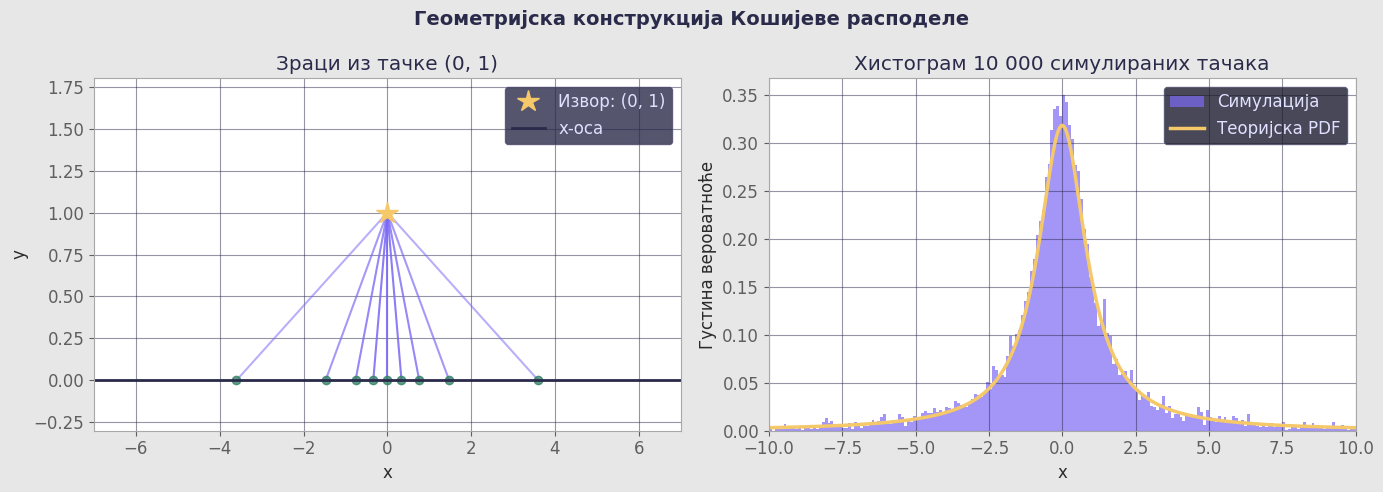

In [ ]:
# Геометријска илустрација: зрак из тачке (0,1) погађа x-осу

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Геометријска конструкција Кошијеве расподеле',
             fontsize=14, fontweight='bold', color=TEXT_COLOR)

# --- Лево: зраци ---
ax = axes[0]
ax.set_title('Зраци из тачке (0, 1)', color=TEXT_COLOR)

for angle in np.linspace(-1.3, 1.3, 9):
    x_hit = np.tan(angle)
    ax.plot([0, x_hit], [1, 0], color=CAUCHY_COLOR,
            alpha=0.4 + 0.5 * abs(np.cos(angle)), linewidth=1.5)
    ax.plot(x_hit, 0, 'o', color=ACCENT_COLOR, markersize=6, alpha=0.8)

ax.plot(0, 1, '*', color=GOLD_COLOR, markersize=16, label='Извор: (0, 1)', zorder=5)
ax.axhline(0, color=TEXT_COLOR, linewidth=2, label='x-оса')
ax.set_xlim(-7, 7); ax.set_ylim(-0.3, 1.8)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(facecolor=TEXT_COLOR, edgecolor='#4a4a6a')
ax.grid(True)

# --- Десно: хистограм ---
ax2 = axes[1]
ax2.set_title('Хистограм 10 000 симулираних тачака', color=TEXT_COLOR)

np.random.seed(42)
thetas = np.random.uniform(-np.pi/2, np.pi/2, 10_000)
x_hits = np.tan(thetas)

ax2.hist(x_hits, bins=200, range=(-10, 10), density=True,
         color=CAUCHY_COLOR, alpha=0.7, label='Симулација')

x_plot = np.linspace(-10, 10, 500)
ax2.plot(x_plot, stats.cauchy.pdf(x_plot), color=GOLD_COLOR,
         linewidth=2.5, label='Теоријска PDF')

ax2.set_xlim(-10, 10)
ax2.set_xlabel('x'); ax2.set_ylabel('Густина вероватноће')
ax2.legend(facecolor='#1a1a2e', edgecolor='#4a4a6a')
ax2.grid(True)

plt.tight_layout()
plt.show()

---
## 3. Математичка дефиниција

### 3.1 Функција густине вероватноће (PDF)

Кажемо да случајна променљива $X$ прати **Кошијеву расподелу** са параметрима $x_0$ (локација) и $\gamma > 0$ (скала) и пишемо $X \sim \text{Cauchy}(x_0,\ \gamma)$, ако је:

$$\boxed{f(x;\ x_0,\ \gamma) = \frac{1}{\pi\gamma\left[1 + \left(\dfrac{x - x_0}{\gamma}\right)^2\right]}}$$

**Параметри:**
- $x_0 \in \mathbb{R}$ — **локација** (положај врха; одговара медијани и моди)
- $\gamma > 0$ — **скала** (ширина криве)

### 3.2 Доказ валидности (смена $u = \frac{x - x_0}{\gamma}$)

$$\int_{-\infty}^{+\infty} f(x)\, dx = \frac{1}{\pi}\int_{-\infty}^{+\infty} \frac{du}{1 + u^2} = \frac{1}{\pi}\Big[\arctan(u)\Big]_{-\infty}^{+\infty} = \frac{1}{\pi}\cdot\pi = 1 \quad \checkmark$$

### 3.3 Функција расподеле (CDF)

$$F(x;\ x_0,\ \gamma) = \frac{1}{\pi}\arctan\!\left(\frac{x - x_0}{\gamma}\right) + \frac{1}{2}$$

In [ ]:
# Интерактивни график — мењај параметре клизачима

def plot_cauchy_interactive(x0, gamma):
    x = np.linspace(-10, 10, 1000)
    pdf = stats.cauchy.pdf(x, loc=x0, scale=gamma)
    cdf = stats.cauchy.cdf(x, loc=x0, scale=gamma)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Кошијева расподела: $x_0 = {x0}$, $\\gamma = {gamma}$',
                 fontsize=14, fontweight='bold', color='#e0e0ff')

    # PDF
    ax1.plot(x, pdf, color=CAUCHY_COLOR, linewidth=2.5, label='Кошијева PDF')
    ax1.axvline(x0, color=GOLD_COLOR, linestyle='--', alpha=0.8,
                label=f'Локација $x_0 = {x0}$')
    half_max = stats.cauchy.pdf(x0, loc=x0, scale=gamma)
    ax1.set_title('Функција густине вероватноће (PDF)', color='#e0e0ff')
    ax1.set_xlabel('x'); ax1.set_ylabel('f(x)')
    ax1.set_ylim(0, 0.45)
    ax1.legend(facecolor='#1a1a2e', edgecolor='#4a4a6a')
    ax1.grid(True)

    # CDF
    ax2.plot(x, cdf, color=NORMAL_COLOR, linewidth=2.5, label='Кошијева CDF')
    ax2.axvline(x0, color=GOLD_COLOR, linestyle='--', alpha=0.8,
                label=f'Медијана = $x_0 = {x0}$')
    ax2.axhline(0.5, color=GOLD_COLOR, linestyle=':', alpha=0.6)
    ax2.set_title('Функција расподеле (CDF)', color='#e0e0ff')
    ax2.set_xlabel('x'); ax2.set_ylabel('F(x)')
    ax2.legend(facecolor='#1a1a2e', edgecolor='#4a4a6a')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

x0_slider    = widgets.FloatSlider(value=0, min=-5, max=5, step=0.5,
                description='x0 (локација):', style={'description_width': '130px'},
                layout=widgets.Layout(width='450px'))
gamma_slider = widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1,
                description='gamma (скала):', style={'description_width': '130px'},
                layout=widgets.Layout(width='450px'))

ui  = widgets.VBox([x0_slider, gamma_slider])
out = widgets.interactive_output(plot_cauchy_interactive,
                                  {'x0': x0_slider, 'gamma': gamma_slider})
display(ui, out)

Output()

---
## 4. Необична својства

### 4.1 Нема очекивање!

За Кошијеву расподелу покушавамо да израчунамо:

$$E[X] = \int_{-\infty}^{+\infty} \frac{x}{\pi(1 + x^2)}\, dx$$

Сменом $u = 1 + x^2$:

$$\frac{1}{2\pi}\int_1^{\infty} \frac{du}{u} - \frac{1}{2\pi}\int_1^{\infty} \frac{du}{u} = \frac{1}{2\pi}[\ln u]_1^{\infty} - \frac{1}{2\pi}[\ln u]_1^{\infty}$$

Оба дела **дивергирају** — интеграл **не постоји**.

> ⚠️ Расподела је симетрична, па симетрични интеграл даје 0 (Кошијева главна вредност), али **очекивање не постоји** јер $\int |x|\, f(x)\, dx = \infty$.

### 4.2 Шта постоји, а шта не?

| Величина | Нормална расподела | Кошијева расподела |
|---|---|---|
| Очекивање | ✓ постоји ($\mu$) | ✗ не постоји |
| Варијанса | ✓ постоји ($\sigma^2$) | ✗ не постоји |
| Медијана | ✓ $= \mu$ | ✓ $= x_0$ |
| Мода | ✓ $= \mu$ | ✓ $= x_0$ |

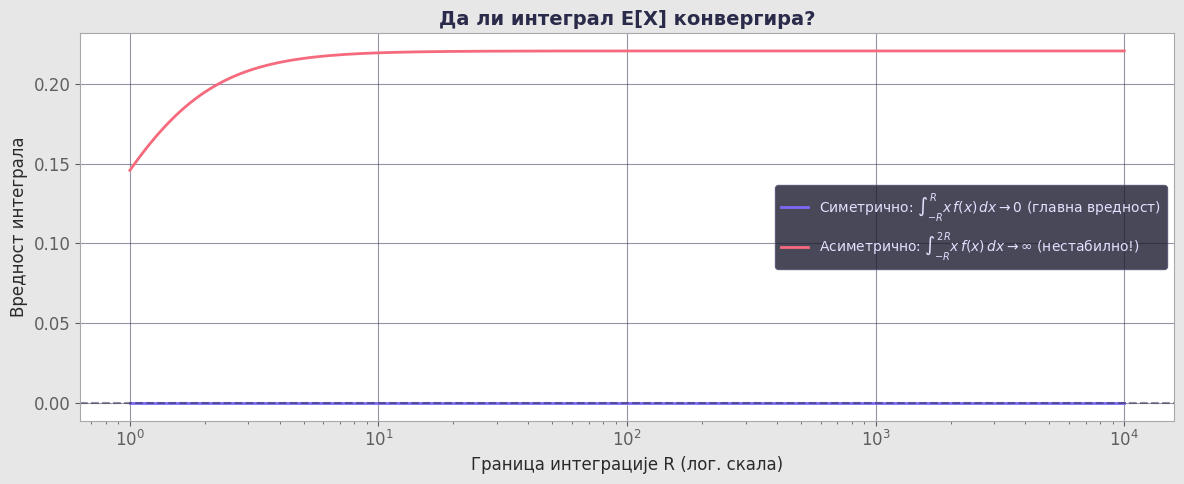

Закључак: резултат зависи од тога до КУД интегришемо
=> то значи да очекивање не постоји!


In [ ]:
# Нумеричка демонстрација: интеграл E[X] не конвергира

R_values         = np.logspace(0, 4, 200)
principal_values = []
asymmetric_values = []

for R in R_values:
    # Симетрични интеграл (главна вредност)
    val, _ = quad(lambda x: x * stats.cauchy.pdf(x), -R, R)
    principal_values.append(val)
    # Асиметрични интеграл — показује нестабилност
    val2, _ = quad(lambda x: x * stats.cauchy.pdf(x), -R, 2 * R)
    asymmetric_values.append(val2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Да ли интеграл E[X] конвергира?',
             fontsize=14, fontweight='bold', color=TEXT_COLOR)

ax.semilogx(R_values, principal_values, color=CAUCHY_COLOR, linewidth=2,
            label=r'Симетрично: $\int_{-R}^{R} x\,f(x)\,dx \to 0$ (главна вредност)')
ax.semilogx(R_values, asymmetric_values, color=NORMAL_COLOR, linewidth=2,
            label=r'Асиметрично: $\int_{-R}^{2R} x\,f(x)\,dx \to \infty$ (нестабилно!)')

ax.axhline(0, color=TEXT_COLOR, linestyle='--', alpha=0.5)
ax.set_xlabel('Граница интеграције R (лог. скала)')
ax.set_ylabel('Вредност интеграла')
ax.legend(facecolor='#1a1a2e', edgecolor='#4a4a6a', fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()

print('Закључак: резултат зависи од тога до КУД интегришемо')
print('=> то значи да очекивање не постоји!')

---
## 5. Тешки репови — поређење са нормалном расподелом

Кошијева расподела је класичан пример расподеле са **тешким (heavy) реповима**.

**Брзина опадања:**
- Нормална расподела: $f(x) \sim e^{-x^2/2}$ — **експоненцијални** пад
- Кошијева расподела: $f(x) \sim \dfrac{1}{\pi x^2}$ — **алгебарски (полиномни)** пад

На пример, за $x = 10$: нормална даје $e^{-50} \approx 10^{-22}$, а Кошијева $\frac{1}{100\pi} \approx 0.003$ — разлика је **20 редова величине**!

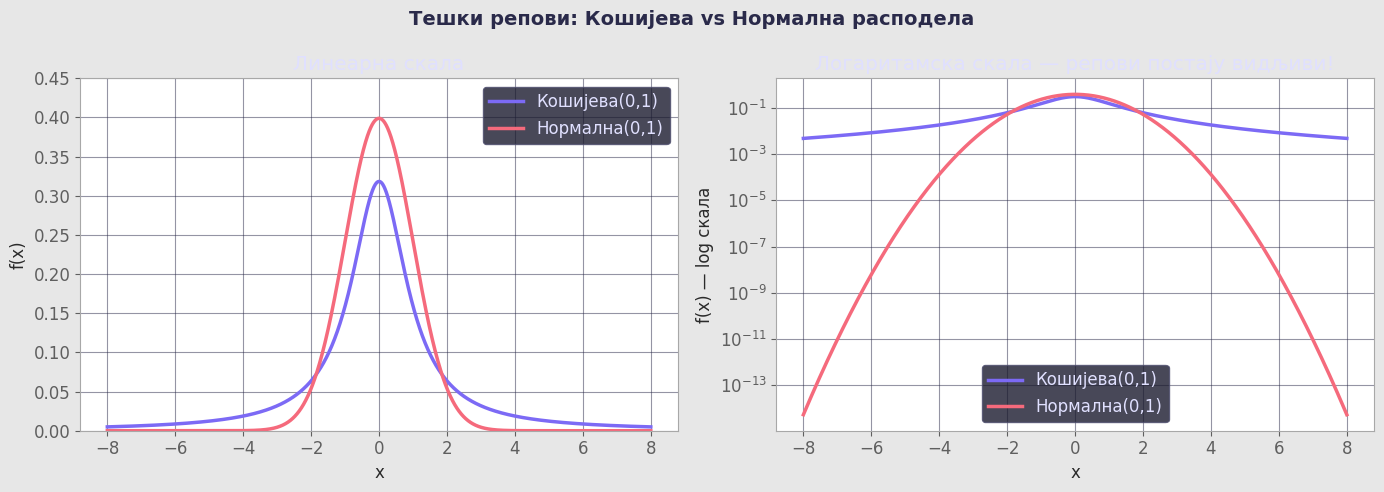

Нумеричко поређење:

    x |    Нормална P(X>x) |    Кошијева P(X>x) |      Однос
------------------------------------------------------------
    1 |          1.587e-01 |          2.500e-01 |       1.6x
    2 |          2.275e-02 |          1.476e-01 |       6.5x
    3 |          1.350e-03 |          1.024e-01 |      75.9x
    5 |          2.867e-07 |          6.283e-02 |  219196.3x
   10 |          7.620e-24 |          3.173e-02 | 4163534037987429449728.0x


In [ ]:
# Поређење тешких репова: Кошијева vs Нормална

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Тешки репови: Кошијева vs Нормална расподела',
             fontsize=14, fontweight='bold', color=TEXT_COLOR)

x = np.linspace(-8, 8, 2000)
cauchy_pdf = stats.cauchy.pdf(x)
normal_pdf = stats.norm.pdf(x)

# Линеарна скала
ax1.plot(x, cauchy_pdf, color=CAUCHY_COLOR, linewidth=2.5, label='Кошијева(0,1)')
ax1.plot(x, normal_pdf, color=NORMAL_COLOR, linewidth=2.5, label='Нормална(0,1)')
ax1.set_title('Линеарна скала', color='#e0e0ff')
ax1.set_xlabel('x'); ax1.set_ylabel('f(x)')
ax1.set_ylim(0, 0.45)
ax1.legend(facecolor='#1a1a2e', edgecolor='#4a4a6a')
ax1.grid(True)

# Логаритамска скала — репови постају видљиви
ax2.semilogy(x, cauchy_pdf, color=CAUCHY_COLOR, linewidth=2.5, label='Кошијева(0,1)')
ax2.semilogy(x, normal_pdf, color=NORMAL_COLOR, linewidth=2.5, label='Нормална(0,1)')
ax2.set_title('Логаритамска скала — репови постају видљиви!', color='#e0e0ff')
ax2.set_xlabel('x'); ax2.set_ylabel('f(x) — log скала')
ax2.legend(facecolor='#1a1a2e', edgecolor='#4a4a6a')
ax2.grid(True, which='both')

plt.tight_layout()
plt.show()

# Нумеричко поређење
print("Нумеричко поређење:")
print()
print(f'{"x":>5} | {"Нормална P(X>x)":>18} | {"Кошијева P(X>x)":>18} | {"Однос":>10}')
print('-' * 60)
for xv in [1, 2, 3, 5, 10]:
    pn = stats.norm.sf(xv)
    pc = stats.cauchy.sf(xv)
    print(f'{xv:>5} | {pn:>18.3e} | {pc:>18.3e} | {pc/pn:>9.1f}x')

---
## 6. Закон великих бројева — зашто не важи?

**Закон великих бројева** каже: ако случајна променљива има **коначно очекивање**, просек великог узорка конвергира ка том очекивању.

Пошто Кошијева расподела **нема коначно очекивање**, ЗВБ не примењујемо — и то ћемо видети визуелно: просек узорка **никад не стабилизује**, без обзира на величину узорка.

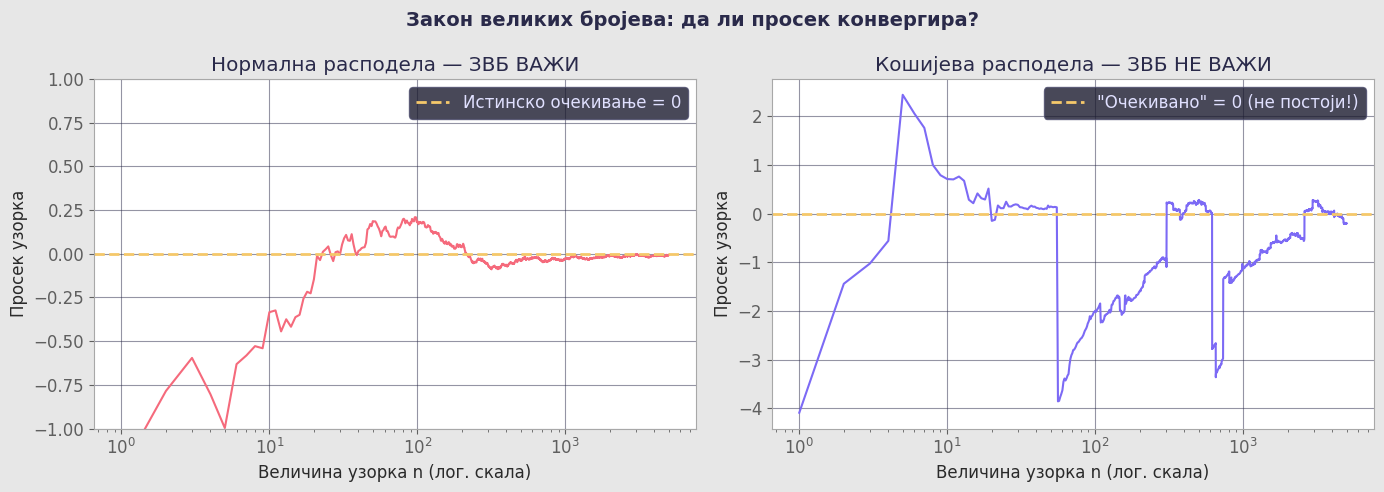

In [ ]:
# Симулација: кумулативни просек — Кошијева vs Нормална

np.random.seed(7)
n_samples = 5000

cauchy_samples = stats.cauchy.rvs(size=n_samples)
normal_samples = stats.norm.rvs(size=n_samples)

ns = np.arange(1, n_samples + 1)
cauchy_cumavg = np.cumsum(cauchy_samples) / ns
normal_cumavg = np.cumsum(normal_samples) / ns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Закон великих бројева: да ли просек конвергира?',
             fontsize=14, fontweight='bold', color=TEXT_COLOR)

ax1.semilogx(ns, normal_cumavg, color=NORMAL_COLOR, linewidth=1.5)
ax1.axhline(0, color=GOLD_COLOR, linestyle='--', linewidth=2, label='Истинско очекивање = 0')
ax1.set_title('Нормална расподела — ЗВБ ВАЖИ', color=TEXT_COLOR)
ax1.set_xlabel('Величина узорка n (лог. скала)')
ax1.set_ylabel('Просек узорка')
ax1.set_ylim(-1, 1)
ax1.legend(facecolor='#1a1a2e', edgecolor='#4a4a6a')
ax1.grid(True)

ax2.semilogx(ns, cauchy_cumavg, color=CAUCHY_COLOR, linewidth=1.5)
ax2.axhline(0, color=GOLD_COLOR, linestyle='--', linewidth=2,
            label='"Очекивано" = 0 (не постоји!)')
ax2.set_title('Кошијева расподела — ЗВБ НЕ ВАЖИ', color=TEXT_COLOR)
ax2.set_xlabel('Величина узорка n (лог. скала)')
ax2.set_ylabel('Просек узорка')
ax2.legend(facecolor='#1a1a2e', edgecolor='#4a4a6a')
ax2.grid(True)

plt.tight_layout()
plt.show()

---
## 7. Стабилност Кошијеве расподеле

Ако $X_1, X_2 \sim \text{Cauchy}(0,1)$ независне:

$$X_1 + X_2 \sim \text{Cauchy}(0, 2)$$

Просек $\dfrac{X_1 + X_2}{2} \sim \text{Cauchy}(0, 1)$ — **исто као оригинал!** Зато просек никад не конвергира.

In [ ]:
# Стабилност
c1, c2  = stats.cauchy.rvs(size=n), stats.cauchy.rvs(size=n)
zbir    = c1 + c2
prosek  = zbir / 2
print('--- Стабилност Кошијеве расподеле ---')
print(f'c1              IQR = {stats.iqr(c1):.3f}       (Cauchy(0,1))')
print(f'c2              IQR = {stats.iqr(c2):.3f}       (Cauchy(0,1))')
print(f'c1+c2           IQR = {stats.iqr(zbir):.3f}       (Cauchy(0,2) — скала се удвостручила)')
print(f'(c1+c2)/2       IQR = {stats.iqr(prosek):.3f}       (Cauchy(0,1) — исто као оригинал!)')

--- Стабилност Кошијеве расподеле ---
c1              IQR = 2.002       (Cauchy(0,1))
c2              IQR = 1.999       (Cauchy(0,1))
c1+c2           IQR = 4.024       (Cauchy(0,2) — скала се удвостручила)
(c1+c2)/2       IQR = 2.012       (Cauchy(0,1) — исто као оригинал!)


---
## 8. Примене у стварном свету

### 8.1 Физика: Лоренцов спектрални профил

У **квантној механици**, зрачење нестабилног атома има спектралну расподелу:

$$I(\nu) \propto \frac{(\Gamma/2)^2}{(\nu - \nu_0)^2 + (\Gamma/2)^2}$$

— тачно Кошијева расподела са $x_0 = \nu_0$, $\gamma = \Gamma/2$.

### 8.2 Финансије: екстремни тржишни догађаји

Класични модели претпостављају нормалну расподелу приноса — али тржишни падови (1987, 2008) показују да су „репни" догађаји **много чешћи** него нормална расподела предвиђа. Расподеле са тешким реповима боље моделују ризик.

---
## 9. Резиме кључних идеја

| Тема | Кључна порука |
|------|---------------|
| **Дефиниција** | $f(x) = \frac{1}{\pi\gamma[1 + ((x-x_0)/\gamma)^2]}$ — параметри: $x_0$ и $\gamma$ |
| **Геометрија** | Природна конструкција пројекцијом зрака из тачке на x-осу |
| **Очекивање** | **Не постоји** — интеграл дивергира |
| **Варијанса** | **Не постоји** |
| **Тешки репови** | Пад $\sim 1/x^2$, а не $\sim e^{-x^2}$ |
| **ЗВБ** | **Не важи** — просек узорка не конвергира |
| **Стабилност** | Збир Кошијевих остаје Кошијева (само скала расте) |
| **Примене** | Спектроскопија, финансијски ризик |

### Зашто је важна?

Кошијева расподела је **контрапример** за скоро све теореме које претпостављају коначно очекивање:

1. **Интуиција може да вара** — равномерни угао звучи безазлено, а даје расподелу без очекивања.
2. **Претпоставке теорема нису украс** — ЗВБ важи **само под условима**.
3. **Свет није увек нормалан** — тешки репови постоје у природи и финансијама.

---
## Извори

- **Wikipedia**: [Cauchy distribution](https://en.wikipedia.org/wiki/Cauchy_distribution)
- **SciPy документација**: `scipy.stats.cauchy`

---
*Ноутбук израдио: Никола Најић, 4ц*  
*Предмет: Вероватноћа и статистика*